# 2D Likelihood Landscape: Pulsar 0 Distance vs Pulsar 1 Distance

This notebook generates **N** random pulsars and one continuous gravitational
wave (CGW) source, then sweeps the PTA log-likelihood over a 2D grid of:

- **Pulsar 0 distance** (`PX`, in kpc) along the x-axis
- **Pulsar 1 distance** (`PX`, in kpc) along the y-axis

All other pulsars are held at their true (injected) distances.

The CGW pulsar-term phase depends on distance as
$$
\phi_p \;=\; \phi_e \;-\; 2\pi f_{gw}\,\frac{d}{c}\,(1 + \cos\mu),
$$
so the likelihood contribution from each pulsar is periodic in that pulsar's
distance, with period $\Delta d = c / [f_{gw}(1+\cos\mu)]$ set by its own
opening angle $\mu$ relative to the CGW source. The 2D landscape should
therefore show a lattice of Gaussian peaks at the phase-matching degeneracies.

In [ ]:
%matplotlib widget
import matplotlib.pyplot as plt

In [ ]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
import pint.models as pm

from jaxpint.pta.likelihood import pta_logL
from jaxpint.pta.signals.cw import CWInjectorStack
from jaxpint.notebook_utils import (
    generate_random_par,
    inject_and_build_config,
    plot_2d_delta_logL,
    setup_synthetic_pta,
    sweep_2d_logL,
)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 20
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 123


## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [ ]:
rng = np.random.default_rng(SEED)

par_strings = [generate_random_par(idx, rng, start_mjd=START_MJD) for idx in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")


## Generate fake TOAs and convert to JaxPINT

In [ ]:
synthetic = setup_synthetic_pta(
    pint_models,
    start_mjd=START_MJD, end_mjd=END_MJD,
    n_toas=N_TOAS, toa_error_s=TOA_ERROR, freq_mhz=FREQ,
)
pulsar_params_list = list(synthetic.pulsar_params_list)
timing_models = list(synthetic.timing_models)
noise_models = list(synthetic.noise_models)
pp_tuple = synthetic.pulsar_params_list

for i, model in enumerate(pint_models):
    px_val = float(pulsar_params_list[i].param_value("PX"))
    f0 = float(pulsar_params_list[i].param_value("F0"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  F0={f0:.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")


## Set up the CW source and inject into TOAs

We place a single continuous gravitational wave source at a random sky
location with a random nHz-band GW frequency and strain $h = 10^{-14}$.

In [ ]:
# Pulsar unit vectors for CWInjectorStack
positions_np = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    positions_np.append(np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ]))
positions = jnp.array(np.array(positions_np))

TRUE_LOG10_H = -14.0

per_source_values = [
    {
        "log10_h": TRUE_LOG10_H,
        "cos_gwtheta": float(rng.uniform(-1, 1)),
        "gwphi": float(rng.uniform(0, 2 * np.pi)),
        "log10_fgw": float(rng.uniform(-9, -7)),
    }
    for _ in range(M_CW_SOURCES)
]

cw_injector = CWInjectorStack(
    positions, n_sources=M_CW_SOURCES, per_source_values=per_source_values,
)

gp, config = inject_and_build_config(synthetic, (cw_injector,))

print(f"PTA config built with {M_CW_SOURCES} CW sources (single vmapped injector).")
print(f"Global params: {gp.n_params} total")


## 2D likelihood sweep: pulsar 0 distance vs pulsar 1 distance

We sweep `PX` of pulsar 0 (x-axis) against `PX` of pulsar 1 (y-axis), holding
all other parameters (global CW params and all other pulsars' PX) fixed at
their true injected values. The evaluation is a nested `jax.vmap` over both
axes, wrapped in a single `jax.jit`, so the 500&times;500 = 250k-point grid
compiles once and runs fully vectorized.

In [ ]:

HALF_WINDOW_KPC_X = 0.01  
N_GRID_X = 2000          


HALF_WINDOW_KPC_Y = 0.01  
N_GRID_Y = 2000   

PULSAR_A, PULSAR_B = 0, 1

In [ ]:
true_dist_a = float(pulsar_params_list[PULSAR_A].param_value("PX"))
true_dist_b = float(pulsar_params_list[PULSAR_B].param_value("PX"))
print(f"Pulsar {PULSAR_A} true distance: {true_dist_a:.3f} kpc")
print(f"Pulsar {PULSAR_B} true distance: {true_dist_b:.3f} kpc")

dist_a_grid = np.linspace(true_dist_a - HALF_WINDOW_KPC_X,
                          true_dist_a + HALF_WINDOW_KPC_X, N_GRID_X)
dist_b_grid = np.linspace(true_dist_b - HALF_WINDOW_KPC_Y,
                          true_dist_b + HALF_WINDOW_KPC_Y, N_GRID_Y)


def eval_logL_2d(px_a, px_b):
    pp_a = pp_tuple[PULSAR_A].with_value("PX", px_a)
    pp_b = pp_tuple[PULSAR_B].with_value("PX", px_b)
    pp_mod = (pp_a, pp_b) + pp_tuple[2:]
    return pta_logL(gp, pp_mod, config)


# Chunked row sweep: trades a Python loop for bounded memory. chunk_rows=1 is
# the most memory-conservative; raise if you have headroom.
print(f"Computing {N_GRID_X} x {N_GRID_Y} = {N_GRID_X * N_GRID_Y} "
      f"likelihood evaluations (chunked rows)...")
logL_2d = sweep_2d_logL(eval_logL_2d, dist_a_grid, dist_b_grid, chunk_rows=1)
print("Done.")


## 2D pcolormesh plot

The red star marks the true injected (d&#8320;, d&#8321;). Expect a bright
central peak plus a 2D lattice of secondary peaks at the phase-matching
degeneracies. The peak spacings along each axis depend on that pulsar's
opening angle $\mu$ to the CW source, so the two axes generally have
different periodicities.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 8))

mesh = plot_2d_delta_logL(
    ax, dist_a_grid, dist_b_grid, logL_2d,
    # true star marker is commented out in the original; pass None.
    true_xy=None,
)
ax.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)", fontsize=13)
ax.set_ylabel(f"Pulsar {PULSAR_B} distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood landscape: d₀ vs d₁\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, all other params at truth)",
    fontsize=13,
)
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()


## 1D projections along each pulsar distance

Slices through `logL_2d` at the other pulsar's true distance (conditional likelihood, matching the 2D plot's "all other params at truth" convention).

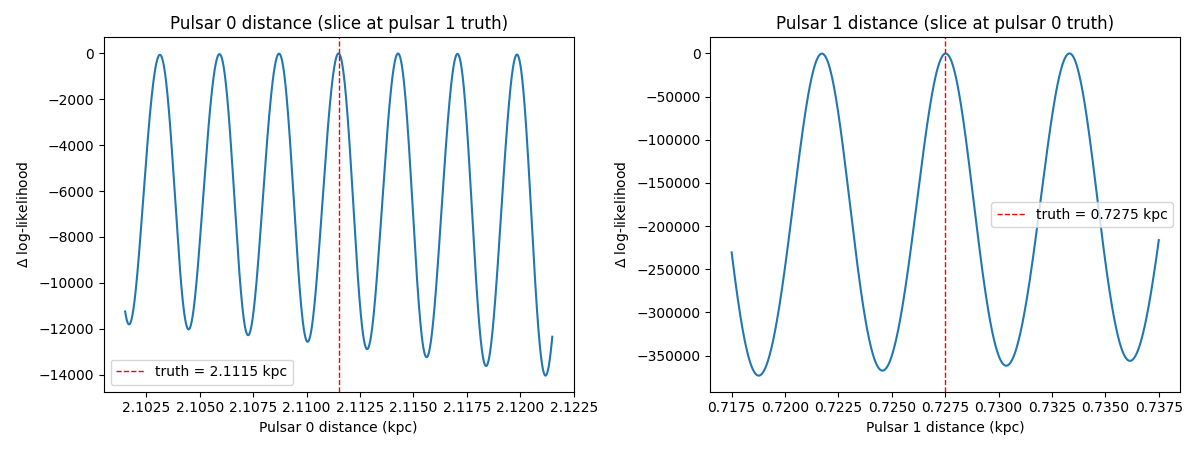

In [ ]:
# Slice 2D grid at the true distance of the other pulsar.
idx_b_true = int(np.argmin(np.abs(np.asarray(dist_b_grid) - true_dist_b)))
idx_a_true = int(np.argmin(np.abs(np.asarray(dist_a_grid) - true_dist_a)))

logL_1d_a = logL_2d[idx_b_true, :]           # vs dist_a, pulsar A
logL_1d_b = logL_2d[:, idx_a_true]           # vs dist_b, pulsar B

delta_a = logL_1d_a - logL_1d_a.max()
delta_b = logL_1d_b - logL_1d_b.max()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

ax0.plot(np.asarray(dist_a_grid), delta_a, lw=1.5)
ax0.axvline(true_dist_a, color="r", ls="--", lw=1, label=f"truth = {true_dist_a:.4f} kpc")
ax0.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)")
ax0.set_ylabel(r"$\Delta$ log-likelihood")
ax0.set_title(f"Pulsar {PULSAR_A} distance (slice at pulsar {PULSAR_B} truth)")
ax0.legend()

ax1.plot(np.asarray(dist_b_grid), delta_b, lw=1.5)
ax1.axvline(true_dist_b, color="r", ls="--", lw=1, label=f"truth = {true_dist_b:.4f} kpc")
ax1.set_xlabel(f"Pulsar {PULSAR_B} distance (kpc)")
ax1.set_ylabel(r"$\Delta$ log-likelihood")
ax1.set_title(f"Pulsar {PULSAR_B} distance (slice at pulsar {PULSAR_A} truth)")
ax1.legend()

fig.tight_layout()
plt.show()